### Application of Machine Learning and Fine-Tuning 
1. Continue with the previous labs, we will use the same dataset to build machine learning models to predict dignosis of breast cancer. 

    In this lab, `students are allowed and encouraged to use libraries such as sklearn.`

2. Train the following machine learning models on the training set and test the performance on the test set:
    - Support Vector Machine [1 point]
    - Decision Tree [1 point]
    - Gradient Boosting [1 point]
    - Random Forest [1 point]
    
For Steps 3, 4, and 5: Successfully complete and print results for all models [2 points], Successfully complete and print results for at least 2 models [1 point], Otherwise [0 point].

3. Run grid search to find the best parameters for each model (set cross validation parameter `cv=5`) and `print` the best parameters found. [2 points]
    
    3.1 Hints for parameter search:
    - For SVM, you can try  C, gamma, etc.
    - For Decision Tree, you can try max_depth, min_samples_split, etc.
    - For Gradient Boosting, you can try n_estimators, learning_rate, etc.
    - For Random Forest, you can try n_estimators, max_depth, min_samples_split, etc.
    
4.  `print` the classification report that shows precision, recall and F1 score, using the best parameters found by grid search. [1 point]

5. Plot the confusion matrix of the test set for each model. [1 point]



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay,f1_score
import numpy as np

In [17]:
data = load_breast_cancer()
X = data.data
y = data.target
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

(569, 30) (569,)


{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        45
           1       0.99      0.96      0.97        69

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



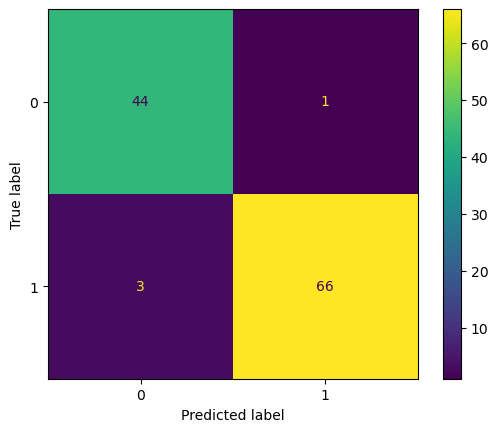

In [22]:
from sklearn import svm

# Initialize SVM classifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xTrainScaled = scaler.fit_transform(X_train)
xTestScaled = scaler.transform(X_test)

svmModel = svm.SVC()

# grid search for best parameters
svmParamGrid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svmGrid = GridSearchCV(svmModel, svmParamGrid, cv=5)

# Fit the model for grid search
svmGrid.fit(xTrainScaled, y_train)

print(svmGrid.best_params_)

# Predict the model using the best parameters
svmGridPredictions = svmGrid.predict(xTestScaled)
print(classification_report(y_test, svmGridPredictions))

# plot confusin matrix
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, svmGridPredictions)
plt.show()

Best parameters {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 4}
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        45
           1       0.94      0.90      0.92        69

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.91      0.90      0.90       114



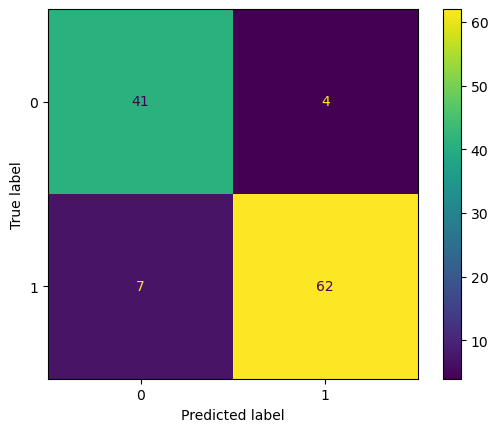

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Initialize decision tree classifier
dtModel = DecisionTreeClassifier()

# grid search CV
dtParamGrid = {
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [2, 4, 6, 10],
    'criterion': ['gini', 'entropy']
}

decisionTreeGrid = GridSearchCV(dtModel, dtParamGrid, cv=5)
decisionTreeGrid.fit(xTrainScaled, y_train)

print('Best parameters', decisionTreeGrid.best_params_)

# print how our model looks after hyper-parameter tuning
decisionTreeGridPredictions = decisionTreeGrid.predict(xTestScaled)

# print classification report 
print(classification_report(y_test, decisionTreeGridPredictions))

# plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, decisionTreeGridPredictions)
plt.show()

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        45
           1       0.96      0.94      0.95        69

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114



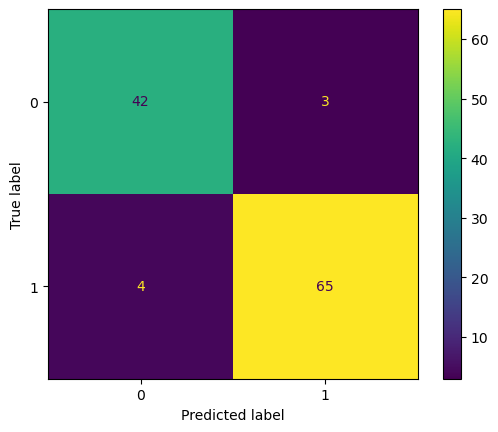

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize gradient boosting classifier
gbcModel = GradientBoostingClassifier()

# param_grid for gradient boosting classifier
gbcParamGrid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [2, 5, 10]
}

gbcGrid = GridSearchCV(gbcModel, gbcParamGrid, cv=5)
gbcGrid.fit(xTrainScaled, y_train)

print(gbcGrid.best_params_) 

# Predict the model using the best parameters
gbcGridPredictions = gbcGrid.predict(xTestScaled)

print('--------------------------------------------------')

# print classification report 
print(classification_report(y_test, gbcGridPredictions))

# plot confusin matrix
ConfusionMatrixDisplay.from_predictions(y_test, gbcGridPredictions)
plt.show()

{'max_depth': 20, 'min_samples_split': 3, 'n_estimators': 50}
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        45
           1       0.97      0.94      0.96        69

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.95       114
weighted avg       0.95      0.95      0.95       114



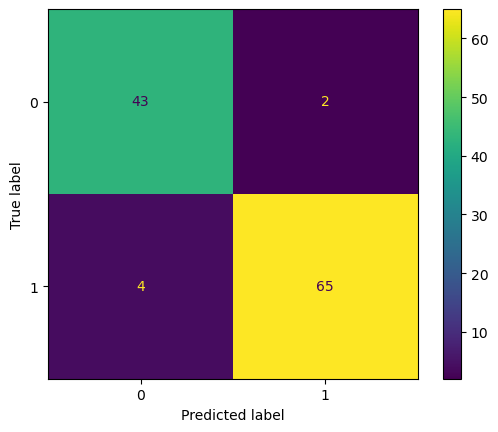

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize random forest classifier
rfModel = RandomForestClassifier()

# grid search for best parameters
rfParamGrid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 3, 5]
}

randomforestGrid = GridSearchCV(rfModel, rfParamGrid, cv=5)
randomforestGrid.fit(xTrainScaled, y_train)

print(randomforestGrid.best_params_) 

# Predict the model using the best parameters
randomforestGridPredictions = randomforestGrid.predict(xTestScaled)

print('--------------------------------------------------')

# print classification report 
print(classification_report(y_test, randomforestGridPredictions))

# plot confusin matrix
ConfusionMatrixDisplay.from_predictions(y_test, randomforestGridPredictions)
plt.show()